In [114]:
import numpy as np
import matplotlib.pyplot as plt

In [115]:
# generate 2D Gaussian Data x= input, mu= mean, C = covariance matrix
def gaussian_2d(x, mean, C):
    difference = x - mean
    inv_C = np.linalg.inv(C)
    exponent = -0.5 * np.sum(difference @ inv_C * difference, axis=1)
    return np.exp(exponent)

In [116]:
def generate_data(N):
    x = np.random.uniform(-4, 4, (N, 2))
    mean = np.array([0, 0])
    C = np.array([[3.0, 0.5], [0.5, 2.0]])
    y = gaussian_2d(x, mean, C)
    return x, y.reshape(-1, 1)

In [117]:
# activation function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [118]:
def sigmoid_derivative(z):
    s = sigmoid(z)
    return s * (1 - s)

In [119]:
class MLP:
    def __init__(self, input_size, hidden_size, lr=0.01):
        self.lr = lr

        self.w1 = np.random.randn(hidden_size, input_size)  * 0.1
        self.b1 = np.zeros((hidden_size, 1))

        self.w2 = np.random.randn(1, hidden_size)  * 0.1
        self.b2 = np.zeros((1, 1))

    def forward(self, x):
        self.x = x.reshape(-1, 1)

        self.z1 = self.w1 @ self.x + self.b1
        self.out1 = sigmoid(self.z1)

        self.z2 = self.w2 @ self.out1 + self.b2
        self.y_pred = self.z2

        return self.y_pred
    
    def backward(self, y_true):
        y_true = y_true.reshape(1,1)

        # output layer error
        dz2 = self.y_pred - y_true

        dw2 = dz2 @ self.out1.T
        db2 = dz2

        # Hidden layer error
        dz1 = (self.w2.T @ dz2) * sigmoid_derivative(self.z1)

        dw1 = dz1 @ self.x.T
        db1 = dz1

        # update weights
        self.w2 = self.w2 - self.lr * dw2
        self.b2 = self.b2 - self.lr * db2

        self.w1 = self.w1 - self.lr * dw1
        self.b1 = self.b1 - self.lr * db1


In [120]:
def train(model, X, Y, epochs):
    losses = []

    for epoch in range(epochs):
        total_loss = 0

        for x, y in zip(X, Y):
            y_hat = model.forward(x)

            loss = 0.5 * (y_hat - y)**2
            total_loss = total_loss + loss.item()

            model.backward(y)

        losses.append(total_loss / len(X))

        if epoch % 50 == 0:
            print(f"Epoch {epoch}, Loss: {losses[-1]}")

    return losses

In [121]:
def predict(model, X):
    preds = []

    for x in X:
        y_hat = model.forward(x)
        preds.append(y_hat[0][0])

    return np.array(preds)

In [122]:
N = 200
H = 2
EPOCHS = 300
LR = 0.01

In [123]:
# prepare datasets
X_train,y_train = generate_data(N)
X_test, y_test = generate_data(100)

In [124]:
X_train.shape, y_train.shape

((200, 2), (200, 1))

In [125]:
mlp = MLP(input_size=2, hidden_size=H, lr=LR)

In [126]:
losses = train(mlp, X_train, y_train, epochs=300)

Epoch 0, Loss: 0.03480793097248259
Epoch 50, Loss: 0.03234243904173381
Epoch 100, Loss: 0.03234056878044875
Epoch 150, Loss: 0.0323390055668317
Epoch 200, Loss: 0.03233637756342941
Epoch 250, Loss: 0.03233254536791755


In [127]:
y_pred = predict(mlp, X_test)

In [128]:
mse = np.mean((y_pred - y_test.flatten())**2)
print("Test MSE:", mse)


Test MSE: 0.05559788479000946


# Visualization


In [ ]:
def analyze_hidden_nodes(n_train=200, epochs=500):
    h_values = range(1, 10) # Testing H from 1 to 9 
    final_test_errors = []
    
    for h in h_values:
        # Train for a fixed number of epochs
        train(mlp, X_train, y_train, epochs)
        # Record final test error
        y_pred_test = predict(mlp, X_test)
        out_h = sigmoid(np.dot(y_pred_test, mlp.w1))
        out_h_bias = np.column_stack((out_h, np.ones(len(out_h))))
        y_pred_test = np.dot(out_h_bias, mlp.w2)
        final_test_errors.append(np.mean(np.square(y_test - y_pred_test)))

    plt.plot(h_values, final_test_errors, marker='o')
    plt.xlabel('Number of Hidden Units (H)')
    plt.ylabel('Final Test MSE')
    plt.title('Performance against Hidden Nodes')
    plt.show()

analyze_hidden_nodes()

Epoch 0, Loss: 0.023817568868309037
Epoch 50, Loss: 0.02267144803813982
Epoch 100, Loss: 0.02251259012879732
Epoch 150, Loss: 0.02248916311674816
Epoch 200, Loss: 0.022481169564569213
Epoch 250, Loss: 0.022476822936159633
Epoch 300, Loss: 0.022474181931536264
Epoch 350, Loss: 0.022472470674878772
Epoch 400, Loss: 0.022471278155979234
Epoch 450, Loss: 0.02247037952373203


ValueError: shapes (100,) and (2,2) not aligned: 100 (dim 0) != 2 (dim 0)

In [ ]:
def analyze_hidden_nodes(n_train=200, epochs=500):
    h_values = range(1, 10) # Testing H from 1 to 9 [cite: 71]
    final_test_errors = []
    
    for h in h_values:
        # Train for a fixed number of epochs
        for _ in range(epochs):
            train(mlp, X_train, y_train)
            
        # Record final test error
        inputs_test = np.column_stack((X_test, np.ones(len(X_test))))
        out_h = mlp.sigmoid(np.dot(inputs_test, mlp.w1))
        out_h_bias = np.column_stack((out_h, np.ones(len(out_h))))
        y_pred_test = np.dot(out_h_bias, mlp.w2)
        final_test_errors.append(np.mean(np.square(y_test - y_pred_test)))

    plt.plot(h_values, final_test_errors, marker='o')
    plt.xlabel('Number of Hidden Units (H)')
    plt.ylabel('Final Test MSE')
    plt.title('Performance against Hidden Nodes')
    plt.show()

analyze_hidden_nodes()

TypeError: 'NoneType' object cannot be interpreted as an integer

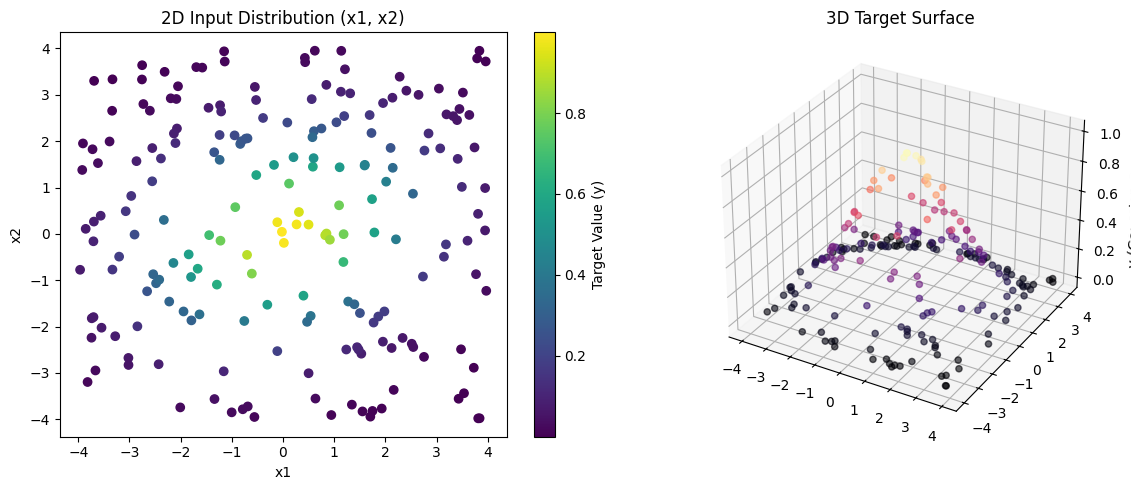

In [ ]:

def visualize_data_distribution(X, y):
    fig = plt.figure(figsize=(12, 5))

    # Plot 1: 2D Scatter Map
    ax1 = fig.add_subplot(121)
    scatter = ax1.scatter(X[:, 0], X[:, 1], c=y.flatten(), cmap='viridis')
    plt.colorbar(scatter, ax=ax1, label='Target Value (y)')
    ax1.set_title('2D Input Distribution (x1, x2)')
    ax1.set_xlabel('x1')
    ax1.set_ylabel('x2')

    # Plot 2: 3D Surface Representation
    ax2 = fig.add_subplot(122, projection='3d')
    ax2.scatter(X[:, 0], X[:, 1], y.flatten(), c=y.flatten(), cmap='magma', alpha=0.6)
    ax2.set_title('3D Target Surface')
    ax2.set_zlabel('y (Gaussian Output)')
    
    plt.tight_layout()
    plt.show()

# Use this with your generated training data
visualize_data_distribution(X_train, y_train)